# Music Context Understanding Using BERT and Graph Neural Networks

# Table of Contents

1. Project Overview
2. Environment Setup
3. Project Configuration
4. Dataset Loading
   - 4.5 Task 1: BERT Multi-Label Tagging (MusicCaps)
5. Exploratory Data Analysis
6. Data Preprocessing
   - 6.12 Baseline Models (Majority Class, PCA + MLP)
7. BERT Baseline Model (FMA genre text)
8. GNN Baseline Model
9. BERT + GNN Fusion Models
   - Concatenation Fusion
   - Cross-Attention Fusion
   - Tag-Aware Gated Fusion
   - Ablation Summary
10. Final Evaluation (Comparison Table, AUC-PR, Plots, Confusion Matrix, t-SNE, Case Studies)
11. Conclusion

## 2.1 Import Libraries

In [1]:

# 2.1 Import Required Libraries



# Basic libraries
import os
import random
import numpy as np
import pandas as pd


# Visualization libraries
import matplotlib.pyplot as plt
import seaborn as sns


# Deep Learning libraries
import torch
import torch.nn as nn
import torch.optim as optim


# Transformers (BERT)
from transformers import BertTokenizer, BertModel


# Evaluation metrics
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    f1_score,
    classification_report,
    confusion_matrix
)


print("Libraries imported successfully")

Libraries imported successfully


## 2.2 Check Hardware Availability

The project requires deep learning models, therefore GPU availability is checked before training.

A GPU can significantly reduce training time for BERT and GNN models.

In [2]:

# 2.2 Hardware Configuration


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

print("Using device:", device)

Using device: cpu


## 2.3 Set Reproducibility

Machine learning experiments can produce slightly different results because of random initialization.

To improve reproducibility, random seeds are fixed for Python, NumPy, and PyTorch.

In [3]:
# 2.3 Reproducibility Setup

SEED = 42


random.seed(SEED)
np.random.seed(SEED)

torch.manual_seed(SEED)


if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)


print("Random seed set to:", SEED)

Random seed set to: 42


Mounting drive

In [4]:
from google.colab import drive

drive.mount('/content/drive')

Mounted at /content/drive


##3. Project Configuration

In [5]:
# 3.1 Define Project Paths


import os


PROJECT_PATH = "/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project"


DATA_PATH = os.path.join(
    PROJECT_PATH,
    "data"
)

RAW_DATA_PATH = os.path.join(
    DATA_PATH,
    "raw"
)

PROCESSED_DATA_PATH = os.path.join(
    DATA_PATH,
    "processed"
)


MUSICCAPS_PATH = os.path.join(
    RAW_DATA_PATH,
    "musiccaps",
    "musiccaps-public.csv"
)


FMA_PATH = os.path.join(
    RAW_DATA_PATH,
    "fma"
)


MODEL_PATH = os.path.join(
    PROJECT_PATH,
    "models"
)


RESULT_PATH = os.path.join(
    PROJECT_PATH,
    "results"
)


print("Project paths configured successfully")

Project paths configured successfully


In [6]:
# 3.2 Create Directories


directories = [
    DATA_PATH,
    RAW_DATA_PATH,
    PROCESSED_DATA_PATH,
    MODEL_PATH,
    RESULT_PATH
]


for directory in directories:
    os.makedirs(
        directory,
        exist_ok=True
    )


print("Directory structure ready")

Directory structure ready


In [7]:
# 3.3 Training Configuration



SEED = 42

BATCH_SIZE = 32

LEARNING_RATE = 1e-4

EPOCHS = 20


NUM_CLASSES = 8


BERT_MODEL_NAME = "bert-base-uncased"


print("Configuration loaded successfully")

Configuration loaded successfully


Verifying file paths


In [8]:
# Check FMA Folder Structure


import os

fma_folder = os.path.join(
    PROJECT_PATH,
    "data",
    "raw",
    "fma"
)


for root, dirs, files in os.walk(fma_folder):

    level = root.replace(fma_folder, "").count(os.sep)

    if level <= 2:
        print(root)

        for f in files[:5]:
            print("   ", f)

/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma
    fma_metadata.zip
    fma_small.zip
/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata
/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata
    README.txt
    checksums
    not_found.pickle
    raw_genres.csv
    raw_albums.csv


In [9]:
# Find FMA Metadata Files


import os

metadata_root = os.path.join(
    FMA_PATH,
    "fma_metadata"
)


for root, dirs, files in os.walk(metadata_root):

    for file in files:

        if file in [
            "tracks.csv",
            "genres.csv",
            "features.csv"
        ]:
            print(
                os.path.join(root, file)
            )

/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata/tracks.csv
/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata/genres.csv
/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata/features.csv


In [10]:
print(os.listdir(
    os.path.join(
        PROJECT_PATH,
        "data",
        "raw",
        "musiccaps"
    )
))

['musiccaps-public.csv']


## 4. Dataset Loading


In [11]:
# 4.1 Dataset Paths


FMA_METADATA_PATH = os.path.join(
    FMA_PATH,
    "fma_metadata",
    "fma_metadata"
)


TRACKS_PATH = os.path.join(
    FMA_METADATA_PATH,
    "tracks.csv"
)


GENRES_PATH = os.path.join(
    FMA_METADATA_PATH,
    "genres.csv"
)


FEATURES_PATH = os.path.join(
    FMA_METADATA_PATH,
    "features.csv"
)


print(TRACKS_PATH)
print(GENRES_PATH)
print(FEATURES_PATH)

/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata/tracks.csv
/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata/genres.csv
/content/drive/MyDrive/CSE425_GNN_BERT_Music_Context_Project/data/raw/fma/fma_metadata/fma_metadata/features.csv


In [12]:
# 4.2 Load MusicCaps Dataset



musiccaps = pd.read_csv(
    MUSICCAPS_PATH
)


print(
    "MusicCaps shape:",
    musiccaps.shape
)


musiccaps.head()

MusicCaps shape: (5521, 9)


,ytid,start_s,end_s,audioset_positive_labels,aspect_list,caption,author_id,is_balanced_subset,is_audioset_eval
0,-0Gj8-vB1q4,30,40,"/m/0140xf,/m/02cjck,/m/04rlf","['low quality', 'sustained strings melody', 's...",The low quality recording features a ballad so...,4,False,True
1,-0SdAVK79lg,30,40,"/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf...","['guitar song', 'piano backing', 'simple percu...",This song features an electric guitar as the m...,0,False,False
2,-0vPFx-wRRI,30,40,"/m/025_jnm,/m/04rlf","['amateur recording', 'finger snipping', 'male...",a male voice is singing a melody with changing...,6,False,True
3,-0xzrMun0Rs,30,40,"/m/01g90h,/m/04rlf","['backing track', 'jazzy', 'digital drums', 'p...",This song contains digital drums playing a sim...,6,False,True
4,-1LrH01Ei1w,30,40,"/m/02p0sh1,/m/04rlf","['rubab instrument', 'repetitive melody on dif...",This song features a rubber instrument being p...,0,False,False


In [13]:
#4.3 Load FMA Metadata



tracks = pd.read_csv(
    TRACKS_PATH,
    header=[0,1],
    index_col=0
)


genres = pd.read_csv(
    GENRES_PATH
)


features = pd.read_csv(
    FEATURES_PATH,
    header=[0,1],
    index_col=0
)


print(
    "Tracks:",
    tracks.shape
)

print(
    "Genres:",
    genres.shape
)

print(
    "Features:",
    features.shape
)

/tmp/ipykernel_695/2705422834.py:17: DtypeWarning: Columns (0) have mixed types. Specify dtype option on import or set low_memory=False.
  features = pd.read_csv(


Tracks: (106574, 52)
Genres: (163, 5)
Features: (106576, 518)


In [14]:
# 4.4 Dataset Preview

print("MusicCaps")
display(
    musiccaps.head()
)
print("\nGenres")
display(
    genres.head()
)
print("\nTracks")
display(
    tracks.head()
)

MusicCaps


,ytid,start_s,end_s,audioset_positive_labels,aspect_list,caption,author_id,is_balanced_subset,is_audioset_eval
0,-0Gj8-vB1q4,30,40,"/m/0140xf,/m/02cjck,/m/04rlf","['low quality', 'sustained strings melody', 's...",The low quality recording features a ballad so...,4,False,True
1,-0SdAVK79lg,30,40,"/m/0155w,/m/01lyv,/m/0342h,/m/042v_gx,/m/04rlf...","['guitar song', 'piano backing', 'simple percu...",This song features an electric guitar as the m...,0,False,False
2,-0vPFx-wRRI,30,40,"/m/025_jnm,/m/04rlf","['amateur recording', 'finger snipping', 'male...",a male voice is singing a melody with changing...,6,False,True
3,-0xzrMun0Rs,30,40,"/m/01g90h,/m/04rlf","['backing track', 'jazzy', 'digital drums', 'p...",This song contains digital drums playing a sim...,6,False,True
4,-1LrH01Ei1w,30,40,"/m/02p0sh1,/m/04rlf","['rubab instrument', 'repetitive melody on dif...",This song features a rubber instrument being p...,0,False,False



Genres


,genre_id,#tracks,parent,title,top_level
0,1,8693,38,Avant-Garde,38
1,2,5271,0,International,2
2,3,1752,0,Blues,3
3,4,4126,0,Jazz,4
4,5,4106,0,Classical,5



Tracks


album                                                     \
         comments         date_created        date_released engineer   
track_id                                                               
2               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
3               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
5               0  2008-11-26 01:44:45  2009-01-05 00:00:00      NaN   
10              0  2008-11-26 01:45:08  2008-02-06 00:00:00      NaN   
20              0  2008-11-26 01:45:05  2009-01-06 00:00:00      NaN   

                                                                          \
         favorites id                                information listens   
track_id                                                                   
2                4  1                                    <p></p>    6073   
3                4  1                                    <p></p>    6073   
5                4  1                                    <p></p>    6073   
10               4  6                                        NaN   47632   
20               2  4  <p> "spiritual songs" from Nicky Cook</p>    2710   

                        ...       track                         \
         producer tags  ... information interest language_code   
track_id                ...                                      
2             NaN   []  ...         NaN     4656            en   
3             NaN   []  ...         NaN     1470            en   
5             NaN   []  ...         NaN     1933            en   
10            NaN   []  ...         NaN    54881            en   
20            NaN   []  ...         NaN      978            en   

                                                                              \
                                                    license listens lyricist   
track_id                                                                       
2         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1293      NaN   
3         Attribution-NonCommercial-ShareAlike 3.0 Inter...     514      NaN   
5         Attribution-NonCommercial-ShareAlike 3.0 Inter...    1151      NaN   
10        Attribution-NonCommercial-NoDerivatives (aka M...   50135      NaN   
20        Attribution-NonCommercial-NoDerivatives (aka M...     361      NaN   

                                                 
         number publisher tags            title  
track_id                                         
2             3       NaN   []             Food  
3             4       NaN   []     Electric Ave  
5             6       NaN   []       This World  
10            1       NaN   []          Freeway  
20            3       NaN   []  Spiritual Level  

[5 rows x 52 columns]

## 5. Exploratory Data Analysis


In [15]:
# 5.1 Import EDA Libraries

import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import numpy as np

print("EDA libraries imported successfully")

EDA libraries imported successfully


In [16]:
# 5.2 Dataset Information


print("MusicCaps Dataset")
print("-----------------")
print(musiccaps.info())

print("\nFMA Tracks Dataset")
print("-----------------")
print(tracks.info())

print("\nFMA Genres Dataset")
print("-----------------")
print(genres.info())

print("\nFMA Features Dataset")
print("-----------------")
print(features.info())

MusicCaps Dataset
-----------------
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5521 entries, 0 to 5520
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   ytid                      5521 non-null   object
 1   start_s                   5521 non-null   int64 
 2   end_s                     5521 non-null   int64 
 3   audioset_positive_labels  5521 non-null   object
 4   aspect_list               5521 non-null   object
 5   caption                   5521 non-null   object
 6   author_id                 5521 non-null   int64 
 7   is_balanced_subset        5521 non-null   bool  
 8   is_audioset_eval          5521 non-null   bool  
dtypes: bool(2), int64(3), object(4)
memory usage: 312.8+ KB
None

FMA Tracks Dataset
-----------------
<class 'pandas.core.frame.DataFrame'>
Index: 106574 entries, 2 to 155320
Data columns (total 52 columns):
 #   Column                       Non-Null Count   Dty

In [17]:
# 5.3 Missing Values



print("MusicCaps Missing Values")
display(
    musiccaps.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)


print("Tracks Missing Values")
display(
    tracks.isnull()
    .sum()
    .sort_values(
        ascending=False
    )
    .head(10)
)

MusicCaps Missing Values


,0
ytid,0
start_s,0
end_s,0
audioset_positive_labels,0
aspect_list,0
caption,0
author_id,0
is_balanced_subset,0
is_audioset_eval,0


Tracks Missing Values


track   lyricist             106263
        publisher            105311
        information          104225
        composer             102904
artist  active_year_end      101199
        wikipedia_page       100993
track   date_recorded        100415
artist  related_projects      93422
        associated_labels     92303
track   language_code         91550
dtype: int64

In [18]:
# 5.4 Caption Length Analysis


musiccaps["caption_length"] = (
    musiccaps["caption"]
    .astype(str)
    .apply(
        lambda x: len(x.split())
    )
)


print(
    musiccaps["caption_length"]
    .describe()
)

count    5521.000000
mean       48.968303
std        17.329780
min         3.000000
25%        37.000000
50%        46.000000
75%        60.000000
max       136.000000
Name: caption_length, dtype: float64


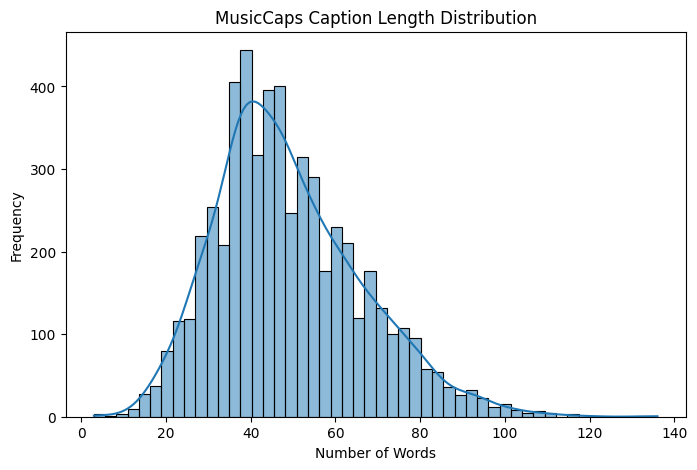

In [19]:
# 5.5 Caption Length Distribution

plt.figure(figsize=(8,5))

sns.histplot(
    musiccaps["caption_length"],
    bins=50,
    kde=True
)

plt.title(
    "MusicCaps Caption Length Distribution"
)

plt.xlabel(
    "Number of Words"
)

plt.ylabel(
    "Frequency"
)

plt.show()

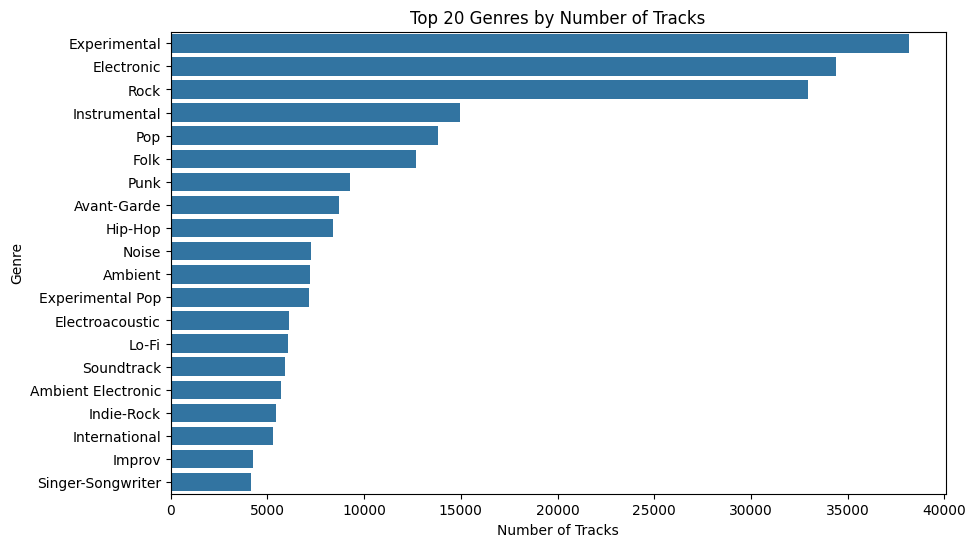

In [20]:
# 5.6 Genre Distribution

plt.figure(figsize=(10,6))


sns.barplot(
    data=genres.sort_values(
        "#tracks",
        ascending=False
    ).head(20),
    x="#tracks",
    y="title"
)


plt.title(
    "Top 20 Genres by Number of Tracks"
)


plt.xlabel(
    "Number of Tracks"
)

plt.ylabel(
    "Genre"
)


plt.show()

In [21]:
# 5.7 Feature Statistics


features.describe().T.head(20)

count      mean        std       min       25%  \
feature     statistics                                                       
chroma_cens kurtosis     106575.0  0.440005  32.285372 -1.955806 -0.636594   
            kurtosis.1   106575.0  0.199773  11.120852 -1.936607 -0.665679   
            kurtosis.2   106575.0  0.334708   9.980649 -1.967450 -0.629107   
            kurtosis.3   106575.0  0.270298  19.074470 -3.000000 -0.644744   
            kurtosis.4   106575.0  0.294850  15.025539 -1.921206 -0.656778   
            kurtosis.5   106575.0  0.315688  12.176137 -1.923740 -0.622574   
            kurtosis.6   106575.0  0.273574  16.975923 -1.935382 -0.646797   
            kurtosis.7   106575.0  0.334999  15.486347 -3.000000 -0.635741   
            kurtosis.8   106575.0  0.202021   7.364323 -3.000000 -0.667792   
            kurtosis.9   106575.0  0.285723   8.175272 -3.000000 -0.660292   
            kurtosis.10  106575.0  0.430648  19.343051 -3.000000 -0.636308   
            kurtosis.11  106575.0  0.474122  22.967582 -3.000000 -0.641433   
            max          106575.0  0.622669   0.086202  0.021007  0.571389   
            max.1        106575.0  0.593434   0.083409  0.051882  0.527863   
            max.2        106575.0  0.610023   0.089285  0.054485  0.546874   
            max.3        106575.0  0.588966   0.087890  0.000000  0.517307   
            max.4        106575.0  0.608219   0.090670  0.038674  0.546217   
            max.5        106575.0  0.596043   0.092477  0.021914  0.524485   
            max.6        106575.0  0.590459   0.091592  0.020285  0.518642   
            max.7        106575.0  0.612545   0.092319  0.000000  0.553730   

                              50%       75%          max  
feature     statistics                                    
chroma_cens kurtosis    -0.176543  0.485025  8843.367188  
            kurtosis.1  -0.221117  0.410119  2864.075195  
            kurtosis.2  -0.152701  0.529845  1777.615967  
            kurtosis.3  -0.191018  0.446832  4257.045898  
            kurtosis.4  -0.198022  0.452694  3188.034424  
            kurtosis.5  -0.152085  0.513130  2809.779297  
            kurtosis.6  -0.187953  0.472191  4281.090820  
            kurtosis.7  -0.161462  0.525828  3869.482178  
            kurtosis.8  -0.214531  0.432492  1217.209473  
            kurtosis.9  -0.181827  0.495605  1772.918213  
            kurtosis.10 -0.160666  0.534784  3887.379639  
            kurtosis.11 -0.169869  0.525563  4995.784668  
            max          0.642001  0.684615     1.000000  
            max.1        0.611782  0.661019     2.000000  
            max.2        0.636942  0.680844     3.000000  
            max.3        0.607987  0.660162     4.000000  
            max.4        0.635373  0.679211     5.000000  
            max.5        0.620019  0.670589     6.000000  
            max.6        0.611707  0.663647     7.000000  
            max.7        0.640468  0.682266     8.000000

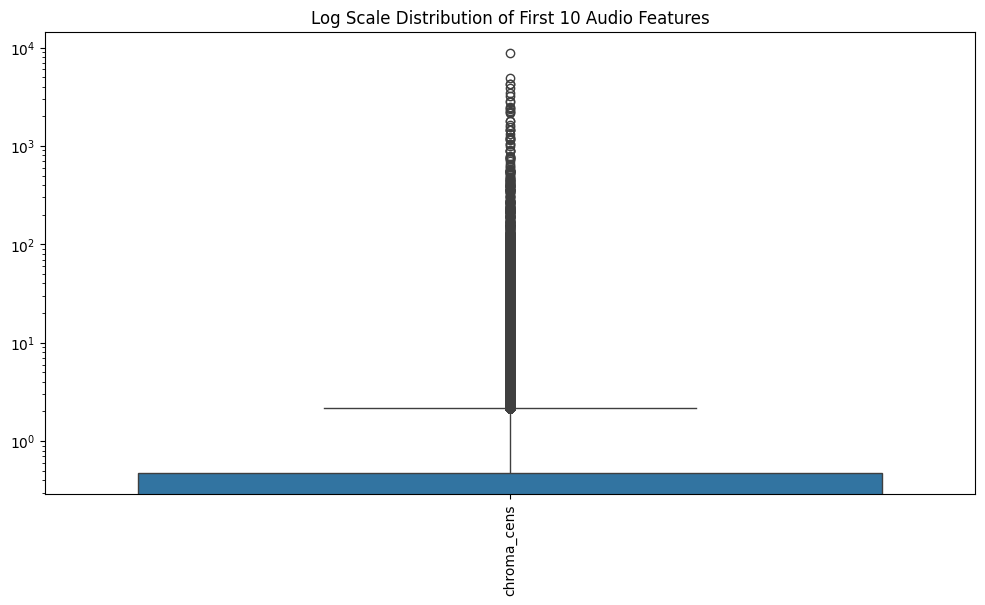

In [22]:
# 5.7 Improved Feature Distribution

feature_sample = features.iloc[:, :10]


plt.figure(figsize=(12,6))


sns.boxplot(
    data=feature_sample
)


plt.xticks(
    rotation=90
)

plt.yscale("log")

plt.title(
    "Log Scale Distribution of First 10 Audio Features"
)


plt.show()

In [23]:
# 5.8 EDA Summary

eda_summary = pd.DataFrame({
    "Dataset": [
        "MusicCaps",
        "FMA Tracks",
        "FMA Genres",
        "FMA Features"
    ],

    "Samples": [
        musiccaps.shape[0],
        tracks.shape[0],
        genres.shape[0],
        features.shape[0]
    ],

    "Features": [
        musiccaps.shape[1],
        tracks.shape[1],
        genres.shape[1],
        features.shape[1]
    ]
})


eda_summary

,Dataset,Samples,Features
0,MusicCaps,5521,10
1,FMA Tracks,106574,52
2,FMA Genres,163,5
3,FMA Features,106576,518


## 4.5 Task 1: BERT Multi-Label Tag Classification (MusicCaps)

This is a standalone implementation of Task 1 as specified: a BERT-based
multi-label classifier over MusicCaps captions, predicting the top-30
most common aspect labels with a sigmoid output per label and BCE loss.
It does not depend on FMA, the GNN, or the fusion pipeline later in this
notebook -- MusicCaps captions are real natural-language descriptions,
so this gives a genuine test of what Task 1 is meant to measure, unlike
the FMA title/tags text used in Section 7.

In [24]:
from transformers import BertTokenizer

tokenizer = BertTokenizer.from_pretrained("bert-base-uncased")

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Tokenizer and device ready:", device)

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

Tokenizer and device ready: cpu


In [25]:
import ast
from collections import Counter


def parse_aspects(value):

    if isinstance(value, list):
        return value

    try:
        return ast.literal_eval(value)
    except (ValueError, SyntaxError):
        return []


musiccaps["parsed_aspects"] = musiccaps["aspect_list"].apply(parse_aspects)


aspect_synonyms = {
    "male voice": "male vocal",
    "male singer": "male vocal",
    "female voice": "female vocal",
    "female singer": "female vocal",
    "e-guitar": "electric guitar",
    "e-bass": "bass guitar",
    "bass": "bass guitar",
    "instrumental music": "instrumental",
    "moderate tempo": "medium tempo",
    "uptempo": "fast tempo"
}


def normalize_aspects(aspects):

    cleaned = []

    for tag in aspects:

        tag = tag.strip().lower()
        tag = aspect_synonyms.get(tag, tag)

        if tag not in cleaned:
            cleaned.append(tag)

    return cleaned


musiccaps["normalized_aspects"] = musiccaps["parsed_aspects"].apply(normalize_aspects)


tag_counts = Counter()

for aspects in musiccaps["normalized_aspects"]:
    tag_counts.update(aspects)


NUM_LABELS = 30

task1_labels = [tag for tag, count in tag_counts.most_common(NUM_LABELS)]

print("Top", NUM_LABELS, "aspect labels for Task 1:")
for i, tag in enumerate(task1_labels, start=1):
    print(f"{i:2d}. {tag} ({tag_counts[tag]})")

Top 30 aspect labels for Task 1:
 1. low quality (1217)
 2. instrumental (1148)
 3. medium tempo (819)
 4. bass guitar (696)
 5. fast tempo (627)
 6. noisy (626)
 7. male vocal (625)
 8. emotional (620)
 9. energetic (593)
10. passionate (592)
11. amateur recording (515)
12. slow tempo (473)
13. live performance (468)
14. electric guitar (444)
15. acoustic drums (393)
16. mono (357)
17. groovy (321)
18. female vocal (306)
19. acoustic guitar (290)
20. piano (239)
21. punchy kick (236)
22. punchy snare (235)
23. groovy bass (228)
24. happy (225)
25. poor audio quality (221)
26. shimmering hi hats (217)
27. rock (207)
28. percussion (206)
29. no voices (202)
30. pop (197)


In [26]:
def make_label_vector(aspects):

    return [
        1 if label in aspects else 0
        for label in task1_labels
    ]


musiccaps["task1_labels"] = musiccaps["normalized_aspects"].apply(make_label_vector)

task1_df = musiccaps[
    musiccaps["task1_labels"].apply(sum) > 0
].copy()


print("Total MusicCaps rows:", len(musiccaps))
print("Usable Task 1 rows (at least one label):", len(task1_df))

Total MusicCaps rows: 5521
Usable Task 1 rows (at least one label): 4921


In [27]:
from sklearn.model_selection import train_test_split


task1_train_df, task1_temp_df = train_test_split(
    task1_df,
    test_size=0.20,
    random_state=42
)

task1_val_df, task1_test_df = train_test_split(
    task1_temp_df,
    test_size=0.50,
    random_state=42
)


print("Train:", len(task1_train_df))
print("Validation:", len(task1_val_df))
print("Test:", len(task1_test_df))

Train: 3936
Validation: 492
Test: 493


In [28]:
from torch.utils.data import Dataset, DataLoader


class MusicCapsDataset(Dataset):

    def __init__(self, dataframe, tokenizer, max_length=128):

        self.dataframe = dataframe.reset_index(drop=True)
        self.tokenizer = tokenizer
        self.max_length = max_length

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):

        row = self.dataframe.iloc[idx]

        encoding = self.tokenizer(
            row["caption"],
            truncation=True,
            padding="max_length",
            max_length=self.max_length,
            return_tensors="pt"
        )

        labels = torch.tensor(row["task1_labels"], dtype=torch.float)

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "labels": labels
        }


task1_train_dataset = MusicCapsDataset(task1_train_df, tokenizer)
task1_val_dataset = MusicCapsDataset(task1_val_df, tokenizer)
task1_test_dataset = MusicCapsDataset(task1_test_df, tokenizer)

task1_train_loader = DataLoader(task1_train_dataset, batch_size=16, shuffle=True)
task1_val_loader = DataLoader(task1_val_dataset, batch_size=16, shuffle=False)
task1_test_loader = DataLoader(task1_test_dataset, batch_size=16, shuffle=False)

print("Train batches:", len(task1_train_loader))
print("Validation batches:", len(task1_val_loader))
print("Test batches:", len(task1_test_loader))

Train batches: 246
Validation batches: 31
Test batches: 31


In [29]:
from transformers import BertForSequenceClassification
from torch.optim import AdamW


task1_model = BertForSequenceClassification.from_pretrained(
    "bert-base-uncased",
    num_labels=len(task1_labels),
    problem_type="multi_label_classification"
).to(device)

task1_optimizer = AdamW(task1_model.parameters(), lr=2e-5)

print("Task 1 model ready, output labels:", task1_model.config.num_labels)

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

model.safetensors: reconstructing file:   0%|          |  0.00B /  440MB            

model.safetensors: downloading bytes:           |  0.00B            

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: bert-base-uncased
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.weight                          | MISSING    | 
classifier.bias                            | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSING:	those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


Task 1 model ready, output labels: 30


In [30]:
def task1_train_epoch(model, loader, optimizer, device):

    model.train()
    total_loss = 0

    for batch in loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["labels"].to(device)

        optimizer.zero_grad()

        outputs = model(
            input_ids=input_ids,
            attention_mask=attention_mask,
            labels=labels
        )

        outputs.loss.backward()
        optimizer.step()

        total_loss += outputs.loss.item()

    return total_loss / len(loader)


def task1_evaluate(model, loader, device, threshold=0.5):

    model.eval()

    all_probs = []
    all_labels = []

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)

            outputs = model(input_ids=input_ids, attention_mask=attention_mask)

            probs = torch.sigmoid(outputs.logits)

            all_probs.append(probs.cpu().numpy())
            all_labels.append(batch["labels"].numpy())

    all_probs = np.vstack(all_probs)
    all_labels = np.vstack(all_labels)

    predictions = (all_probs >= threshold).astype(int)

    micro_f1 = f1_score(all_labels, predictions, average="micro", zero_division=0)
    macro_f1 = f1_score(all_labels, predictions, average="macro", zero_division=0)

    return micro_f1, macro_f1, all_probs, all_labels


print("Task 1 train/eval functions ready")

Task 1 train/eval functions ready


In [ ]:
import copy

EPOCHS = 5
patience = 2

task1_history = {"train_loss": [], "val_micro_f1": [], "val_macro_f1": []}

best_val_macro_f1 = -1
best_state = None
epochs_without_improvement = 0

for epoch in range(EPOCHS):

    train_loss = task1_train_epoch(task1_model, task1_train_loader, task1_optimizer, device)

    val_micro_f1, val_macro_f1, _, _ = task1_evaluate(task1_model, task1_val_loader, device)

    task1_history["train_loss"].append(train_loss)
    task1_history["val_micro_f1"].append(val_micro_f1)
    task1_history["val_macro_f1"].append(val_macro_f1)

    print(f"Epoch {epoch+1}/{EPOCHS} | Loss: {train_loss:.4f} | "
          f"Val Micro-F1: {val_micro_f1:.4f} | Val Macro-F1: {val_macro_f1:.4f}")

    if val_macro_f1 > best_val_macro_f1:
        best_val_macro_f1 = val_macro_f1
        best_state = copy.deepcopy(task1_model.state_dict())
        epochs_without_improvement = 0
    else:
        epochs_without_improvement += 1

    if epochs_without_improvement >= patience:
        print(f"\nEarly stopping at epoch {epoch+1}")
        break

task1_model.load_state_dict(best_state)
print(f"\nBest validation Macro-F1: {best_val_macro_f1:.4f}")

In [ ]:
epochs_range = range(1, len(task1_history["train_loss"]) + 1)

fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(epochs_range, task1_history["train_loss"], marker="o")
axes[0].set_title("Task 1 Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")

axes[1].plot(epochs_range, task1_history["val_micro_f1"], marker="o", label="Micro-F1")
axes[1].plot(epochs_range, task1_history["val_macro_f1"], marker="o", label="Macro-F1")
axes[1].set_title("Task 1 Validation F1 vs Epoch")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
from sklearn.metrics import average_precision_score

test_micro_f1, test_macro_f1, test_probs, test_labels = task1_evaluate(
    task1_model, task1_test_loader, device
)

task1_auc_pr = average_precision_score(test_labels, test_probs, average="macro")

print("Task 1 Test Results")
print("Micro-F1:", test_micro_f1)
print("Macro-F1:", test_macro_f1)
print("Macro AUC-PR:", task1_auc_pr)

In [ ]:
sample_indices = np.random.RandomState(42).choice(len(task1_test_df), size=5, replace=False)

for idx in sample_indices:

    row = task1_test_df.iloc[idx]
    probs = test_probs[idx]

    predicted = [task1_labels[i] for i in range(len(task1_labels)) if probs[i] >= 0.5]
    actual = [task1_labels[i] for i in range(len(task1_labels)) if row["task1_labels"][i] == 1]

    print("Caption:", row["caption"][:150])
    print("Actual labels:", actual)
    print("Predicted labels:", predicted)
    print()

## 6. Data Preprocessing


In [ ]:
# 6.1 Select Required Columns

# MusicCaps text data
musiccaps_data = musiccaps[
    [
        "ytid",
        "caption",
        "aspect_list",
        "audioset_positive_labels"
    ]
].copy()

# FMA genre data
fma_tracks = tracks[
    [
        ("track", "title"),
        ("track", "genre_top"),
        ("set", "subset"),
        ("set", "split")
    ]
].copy()

# Rename
fma_tracks.columns = [
    "title",
    "genre",
    "subset",
    "split"
]

print("MusicCaps:")
display(
    musiccaps_data.head()
)

print("\nFMA Tracks:")
display(
    fma_tracks.head()
)

print("\nFMA subset value counts:")
print(fma_tracks["subset"].value_counts())

print("\nFMA split value counts:")
print(fma_tracks["split"].value_counts())

In [ ]:
# 6.2 Genre Analysis

genre_counts = (
    fma_tracks["genre"]
    .value_counts()
)


genre_counts.head(20)

In [ ]:
# 6.3 Select Target Classes

selected_genres = [
    "Electronic",
    "Experimental",
    "Folk",
    "Hip-Hop",
    "Instrumental",
    "International",
    "Pop",
    "Rock"
]
# Restrict to the official FMA-medium

fma_filtered = fma_tracks[
    (fma_tracks["genre"].isin(selected_genres))
    &
    (fma_tracks["subset"].isin(["small", "medium"]))
].copy()

print(
    "Filtered dataset size (official FMA-medium, "
    "selected genres):",
    fma_filtered.shape
)

fma_filtered["genre"].value_counts()

In [ ]:
# 6.4 Label Encoding

from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
fma_filtered["label"] = (
    label_encoder
    .fit_transform(
        fma_filtered["genre"]
    )
)

print(
    label_encoder.classes_
)

fma_filtered.head()

In [ ]:
# 6.5 Number of Classes

NUM_CLASSES = len(
    label_encoder.classes_
)

print(
    "Number of classes:",
    NUM_CLASSES
)

In [ ]:

# 6.6 Prepare Final Metadata Dataset

# Reset index
fma_filtered = (
    fma_filtered
    .reset_index()
    .rename(
        columns={
            "index":"track_id"
        }
    )
)

print(
    fma_filtered.head()
)
print(
    fma_filtered.shape
)

In [ ]:

# 6.7 Merge Audio Features

# Reset feature index
features_reset = (
    features
    .reset_index()
)


features_reset.head()

In [ ]:
# 6.8 Clean Audio Feature Table



features_clean = pd.read_csv(
    FEATURES_PATH,
    header=[0,1],
    index_col=0,
    low_memory=False
)

# Remove non-track rows
features_clean = features_clean[
    features_clean.index.to_series()
    .astype(str)
    .str.isnumeric()
]

# Convert track IDs
features_clean.index = (
    features_clean.index
    .astype(int)
)

# Reset index
features_clean = (
    features_clean
    .reset_index()
)

# Rename ID column
features_clean = features_clean.rename(
    columns={
        "index": "track_id"
    }
)

print(features_clean.head())


print(
    features_clean.shape
)

In [ ]:
# 6.9 Prepare Features for Merge

# Flatten multi-level feature columns

features_clean.columns = [
    "_".join(
        [str(c) for c in col if str(c) != ""]
    )
    if isinstance(col, tuple)
    else str(col)
    for col in features_clean.columns
]


print(
    features_clean.columns[:10]
)

In [ ]:
# Merge Metadata + Features

fma_dataset = pd.merge(
    fma_filtered,
    features_clean,
    on="track_id",
    how="inner"
)


print(
    "Final FMA Dataset Shape:",
    fma_dataset.shape
)


fma_dataset.head()

In [ ]:
# 6.10 Feature Scaling

from sklearn.preprocessing import StandardScaler

# Select audio features only

audio_features = (
    fma_dataset
    .drop(
        columns=[
            "track_id",
            "title",
            "genre",
            "label",
            "subset",
            "split"
        ]
    )
)

# Labels
y_audio = (
    fma_dataset["label"]
    .values
)

print(
    "Audio feature shape:",
    audio_features.shape
)

print(
    "Labels shape:",
    y_audio.shape
)

In [ ]:
# Standardization

scaler = StandardScaler()

X_audio = scaler.fit_transform(
    audio_features
)

print(
    "Scaled audio shape:",
    X_audio.shape
)

In [ ]:
# Convert to PyTorch Tensor


X_audio_tensor = torch.tensor(
    X_audio,
    dtype=torch.float32
)

y_audio_tensor = torch.tensor(
    y_audio,
    dtype=torch.long
)

print(
    X_audio_tensor.shape
)

print(
    y_audio_tensor.shape
)

In [ ]:
# 6.11 Train Validation Test Split



#FMA's official train/validation/test split
split_labels = fma_dataset["split"].values


train_idx = np.where(split_labels == "training")[0]
val_idx = np.where(split_labels == "validation")[0]
test_idx = np.where(split_labels == "test")[0]


X_train = X_audio_tensor[train_idx]
X_val = X_audio_tensor[val_idx]
X_test = X_audio_tensor[test_idx]

y_train = y_audio_tensor[train_idx]
y_val = y_audio_tensor[val_idx]
y_test = y_audio_tensor[test_idx]


print("Training:", X_train.shape, y_train.shape)
print("Validation:", X_val.shape, y_val.shape)
print("Testing:", X_test.shape, y_test.shape)


# Artist-overlap check
artist_id = (
    tracks.loc[
        fma_dataset["track_id"],
        ("artist", "id")
    ]
    .reset_index(drop=True)
    .values
)

train_artists = set(artist_id[train_idx])
val_artists = set(artist_id[val_idx])
test_artists = set(artist_id[test_idx])

print("\nArtist overlap train/val:", len(train_artists & val_artists))
print("Artist overlap train/test:", len(train_artists & test_artists))
print("Artist overlap val/test:", len(val_artists & test_artists))


print("\nTrain class balance:")
print(
    pd.Series(y_audio_tensor[train_idx].numpy())
    .value_counts(normalize=True)
    .sort_index()
)

print("\nTest class balance:")
print(
    pd.Series(y_audio_tensor[test_idx].numpy())
    .value_counts(normalize=True)
    .sort_index()
)

## 6.12 Baseline Models

Before building the BERT and GNN models, we first establish simple
baselines for comparison, as required by the project rubric (at
least 2 baselines)



In [ ]:
# 6.12.1 Majority Class Baseline (B1)



from collections import Counter


majority_class = Counter(
    y_audio_tensor[train_idx].tolist()
).most_common(1)[0][0]


majority_predictions = np.full(
    len(test_idx),
    majority_class
)


majority_accuracy = accuracy_score(
    y_audio_tensor[test_idx],
    majority_predictions
)


print("Majority class label:", majority_class)
print("Majority Baseline Test Accuracy:", majority_accuracy)

In [ ]:
# 6.12.2 PCA + MLP Baseline (B2)


from sklearn.decomposition import PCA
from sklearn.neural_network import MLPClassifier

pca = PCA(
    n_components=50,
    random_state=42
)

X_audio_train_pca = pca.fit_transform(X_audio[train_idx])
X_audio_val_pca = pca.transform(X_audio[val_idx])
X_audio_test_pca = pca.transform(X_audio[test_idx])

print(
    "Explained variance (50 components):",
    pca.explained_variance_ratio_.sum()
)

pca_mlp = MLPClassifier(
    hidden_layer_sizes=(128, 64),
    max_iter=300,
    random_state=42
)
pca_mlp.fit(
    X_audio_train_pca,
    y_audio_tensor[train_idx].numpy()
)

pca_mlp_predictions = pca_mlp.predict(X_audio_test_pca)


pca_mlp_accuracy = accuracy_score(
    y_audio_tensor[test_idx].numpy(),
    pca_mlp_predictions
)

print("PCA + MLP Baseline Test Accuracy:", pca_mlp_accuracy)
print(
    classification_report(
        y_audio_tensor[test_idx].numpy(),
        pca_mlp_predictions
    )
)

## 7. BERT Baseline Model


In [ ]:
# 7.1 BERT Libraries


import torch
import torch.nn as nn

from torch.utils.data import (
    Dataset,
    DataLoader
)

from transformers import (
    BertTokenizer,
    BertModel
)

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)


print("BERT libraries imported successfully")

In [ ]:
# 7.2 Prepare BERT Text Dataset

import ast

raw_tags = (
    tracks.loc[
        fma_dataset["track_id"],
        ("track", "tags")
    ]
    .reset_index(drop=True)
)


def parse_tags(tag_string):

    try:
        tags = ast.literal_eval(tag_string)

        if isinstance(tags, list) and len(tags) > 0:
            return ", ".join(str(t) for t in tags)

    except (ValueError, SyntaxError):
        pass

    return ""


parsed_tags = raw_tags.apply(parse_tags)


bert_data = fma_dataset[
    [
        "title",
        "genre",
        "label"
    ]
].copy()

bert_data["tags"] = parsed_tags



bert_data["has_tags"] = (parsed_tags != "").astype(int)


def build_text(row):

    if row["tags"]:

        return (
            "The song titled "
            + str(row["title"])
            + " is tagged as: "
            + row["tags"]
            + "."
        )

    return (
        "The song titled "
        + str(row["title"])
        + " is a music track."
    )


bert_data["text"] = bert_data.apply(build_text, axis=1)


bert_data = bert_data[
    [
        "text",
        "label",
        "has_tags"
    ]
]


# Same split indices as the GNN

bert_train = bert_data.iloc[train_idx].reset_index(drop=True)
bert_val = bert_data.iloc[val_idx].reset_index(drop=True)
bert_test = bert_data.iloc[test_idx].reset_index(drop=True)


print("Train:", bert_train.shape)
print("Validation:", bert_val.shape)
print("Test:", bert_test.shape)


print(
    "\nFraction of tracks with real user tags:",
    (parsed_tags != "").mean()
)


tagged_examples = bert_data[bert_data["text"].str.contains("tagged as")]

untagged_examples = bert_data[~bert_data["text"].str.contains("tagged as")]


print("\nSample BERT text (has tags):")
print(
    tagged_examples["text"].iloc[0]
    if len(tagged_examples) > 0
    else "No tagged tracks found in this dataset"
)

print("\nSample BERT text (no tags, fallback):")
print(
    untagged_examples["text"].iloc[0]
    if len(untagged_examples) > 0
    else "All tracks have tags"
)


print("\nBERT test labels:")
print(
    torch.tensor(
        bert_test["label"].values[:10]
    )
)

print("\nAudio test labels:")
print(
    y_audio_tensor[test_idx[:10]]
)

In [ ]:
# 7.3 BERT Tokenization



from transformers import BertTokenizer


tokenizer = BertTokenizer.from_pretrained(
    "bert-base-uncased"
)

print(
    "Tokenizer loaded successfully"
)

In [ ]:
sample_text = bert_data.iloc[0]["text"]


encoding = tokenizer(
    sample_text,
    padding="max_length",
    truncation=True,
    max_length=128,
    return_tensors="pt"
)


print(sample_text)

print(
    encoding.keys()
)

print(
    encoding["input_ids"].shape
)

In [ ]:
# 7.4 BERT Dataset Class


class BERTDataset(Dataset):

    def __init__(
        self,
        dataframe,
        tokenizer,
        max_length=128
    ):

        self.texts = dataframe["text"].values
        self.labels = dataframe["label"].values

        self.tokenizer = tokenizer
        self.max_length = max_length


    def __len__(self):

        return len(self.texts)


    def __getitem__(self, idx):

        text = str(
            self.texts[idx]
        )

        label = self.labels[idx]

        encoding = self.tokenizer(
            text,
            padding="max_length",
            truncation=True,
            max_length=self.max_length,
            return_tensors="pt"
        )

        return {
            "input_ids": encoding["input_ids"].squeeze(0),
            "attention_mask": encoding["attention_mask"].squeeze(0),
            "label": torch.tensor(
                label,
                dtype=torch.long
            )
        }

print("BERT Dataset class created")

In [ ]:
# 7.5 Verify BERT / GNN Split Alignment

#verifying the split alignment

print("Train:", bert_train.shape)
print("Validation:", bert_val.shape)
print("Test:", bert_test.shape)

assert (
    bert_test["label"].values[:10].tolist()
    == y_audio_tensor[test_idx[:10]].tolist()
), "BERT and GNN test splits are misaligned"

print("\nBERT and GNN splits are aligned correctly")

In [ ]:

# Create BERT Dataset Objects

train_dataset = BERTDataset(
    bert_train,
    tokenizer
)

val_dataset = BERTDataset(
    bert_val,
    tokenizer
)

test_dataset = BERTDataset(
    bert_test,
    tokenizer
)

print(
    len(train_dataset),
    len(val_dataset),
    len(test_dataset)
)

In [ ]:

# 7.6 BERT DataLoaders

from torch.utils.data import DataLoader

BATCH_SIZE = 16
train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

val_loader = DataLoader(
    val_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

print(
    "Train batches:",
    len(train_loader)
)

print(
    "Validation batches:",
    len(val_loader)
)

print(
    "Test batches:",
    len(test_loader)
)

In [ ]:

# Check BERT Batch

batch = next(
    iter(train_loader)
)


print(
    batch["input_ids"].shape
)

print(
    batch["attention_mask"].shape
)

print(
    batch["label"].shape
)

In [ ]:
# 7.7 Load BERT Model


from transformers import BertModel
import torch.nn as nn


bert_model = BertModel.from_pretrained(
    "bert-base-uncased"
)

print("BERT model loaded successfully")

In [ ]:
# BERT Classification Model



class BERTClassifier(nn.Module):

    def __init__(self, num_classes):
        super().__init__()
        self.bert = BertModel.from_pretrained(
            "bert-base-uncased"
        )
        self.dropout = nn.Dropout(0.3)
        self.classifier = nn.Linear(
            768,
            num_classes
        )

    def forward(
        self,
        input_ids,
        attention_mask
    ):

        outputs = self.bert(
            input_ids=input_ids,
            attention_mask=attention_mask
        )

        cls_output = outputs.pooler_output

        x = self.dropout(
            cls_output
        )

        logits = self.classifier(x)

        return logits


print("BERT classifier created")

In [ ]:
model = BERTClassifier(num_classes=8)

In [ ]:
# 7.8 Model Setup

device = torch.device(
    "cuda" if torch.cuda.is_available()
    else "cpu"
)

model = BERTClassifier(
    num_classes=8
)

model = model.to(device)

print(
    "Device:",
    device
)

In [ ]:
from torch.optim import AdamW
from sklearn.utils.class_weight import compute_class_weight


optimizer = AdamW(
    model.parameters(),
    lr=2e-5
)


# class-weighted loss--genres are imbalanced

bert_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(bert_train["label"].values),
    y=bert_train["label"].values
)

bert_class_weights_tensor = torch.tensor(
    bert_class_weights,
    dtype=torch.float32
).to(device)


criterion = nn.CrossEntropyLoss(
    weight=bert_class_weights_tensor
)


print("Optimizer and class-weighted loss function created")

In [ ]:
# 7.9 BERT Training Loop



def train_epoch(
    model,
    loader,
    optimizer,
    criterion,
    device
):

    model.train()

    total_loss = 0
    correct = 0
    total = 0


    for batch in loader:

        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        labels = batch["label"].to(device)


        optimizer.zero_grad()


        outputs = model(
            input_ids,
            attention_mask
        )


        loss = criterion(
            outputs,
            labels
        )


        loss.backward()


        optimizer.step()


        total_loss += loss.item()


        predictions = torch.argmax(
            outputs,
            dim=1
        )


        correct += (
            predictions == labels
        ).sum().item()


        total += labels.size(0)


    accuracy = correct / total


    return (
        total_loss / len(loader),
        accuracy
    )


print("Training function created")

In [ ]:
# Validation Function


def evaluate(
    model,
    loader,
    criterion,
    device
):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    all_predictions = []
    all_labels = []


    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)

            attention_mask = batch["attention_mask"].to(device)

            labels = batch["label"].to(device)


            outputs = model(
                input_ids,
                attention_mask
            )


            loss = criterion(
                outputs,
                labels
            )


            total_loss += loss.item()


            predictions = torch.argmax(
                outputs,
                dim=1
            )


            correct += (
                predictions == labels
            ).sum().item()


            total += labels.size(0)

            all_predictions.extend(predictions.cpu().tolist())
            all_labels.extend(labels.cpu().tolist())


    accuracy = correct / total

    # macro-F1, used as the early-stopping criterion below

    macro_f1 = f1_score(
        all_labels,
        all_predictions,
        average="macro"
    )


    return (
        total_loss / len(loader),
        accuracy,
        macro_f1
    )


print("Evaluation function created")

In [ ]:
# 7.9.3 BERT Training Execution


import copy


EPOCHS = 8
patience = 2


history = {
    "train_loss": [],
    "train_acc": [],
    "val_loss": [],
    "val_acc": [],
    "val_macro_f1": []
}

best_val_f1 = -1
best_state = None
epochs_without_improvement = 0


for epoch in range(EPOCHS):

    print(
        f"\nEpoch {epoch+1}/{EPOCHS}"
    )


    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        optimizer,
        criterion,
        device
    )


    val_loss, val_acc, val_macro_f1 = evaluate(
        model,
        val_loader,
        criterion,
        device
    )


    history["train_loss"].append(
        train_loss
    )

    history["train_acc"].append(
        train_acc
    )

    history["val_loss"].append(
        val_loss
    )

    history["val_acc"].append(
        val_acc
    )

    history["val_macro_f1"].append(
        val_macro_f1
    )


    print(
        f"Train Loss: {train_loss:.4f}"
    )

    print(
        f"Train Accuracy: {train_acc:.4f}"
    )

    print(
        f"Validation Loss: {val_loss:.4f}"
    )

    print(
        f"Validation Accuracy: {val_acc:.4f}"
    )

    print(
        f"Validation Macro-F1: {val_macro_f1:.4f}"
    )


    # early stopping on val macro-F1 (val loss was climbing)

    if val_macro_f1 > best_val_f1:

        best_val_f1 = val_macro_f1
        best_state = copy.deepcopy(model.state_dict())
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if epochs_without_improvement >= patience:

        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(no val macro-F1 improvement for {patience} epochs)")

        break


model.load_state_dict(best_state)

print(f"\nBest validation macro-F1: {best_val_f1:.4f}")
print("Training completed (best weights restored)")

In [ ]:
# 7.10 BERT Test Evaluation

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

def predict(
    model,
    loader,
    device
):

    model.eval()

    predictions = []
    actual = []

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)
            attention_mask = batch["attention_mask"].to(device)
            labels = batch["label"].to(device)

            outputs = model(
                input_ids,
                attention_mask
            )
            preds = torch.argmax(
                outputs,
                dim=1
            )
            predictions.extend(
                preds.cpu().numpy()
            )
            actual.extend(
                labels.cpu().numpy()
            )

    return predictions, actual

y_pred, y_true = predict(
    model,
    test_loader,
    device
)

print(
    "Test Accuracy:",
    accuracy_score(y_true, y_pred)
)

print(
    classification_report(
        y_true,
        y_pred
    )
)

## 8. GNN Baseline Model


**Note on graph construction:** the project spec (Section 3)
recommends building *within-track* structure graphs (chord-
transition or segment-similarity graphs from chroma/MFCC frames).
That requires raw audio or beat-synchronous segment features,
which are not available from the FMA `features.csv` metadata used
here -- it only contains one aggregated feature vector per track.

Instead, we build a **track-similarity graph**: each node is a
track, and edges connect each track to its k=5 nearest neighbours
in audio-feature space (cosine similarity). This is a valid and
commonly used GNN setup for genre classification (it turns the
problem into transductive node classification over a corpus-level
similarity graph), but it is a different graph than the literal
per-track chord/segment graph described in the spec -- worth
flagging explicitly in the report as a scoped simplification.

In [ ]:
# Install PyTorch Geometric

!pip install torch-geometric
print("PyTorch Geometric installed")

In [ ]:
# 8.1 GNN Libraries


import torch
import torch.nn as nn
from torch_geometric.data import (
    Data
)

from torch_geometric.nn import (
    GCNConv,
    global_mean_pool
)

from sklearn.neighbors import (
    NearestNeighbors
)

print("GNN libraries imported successfully")

In [ ]:
# 8.2 Construct kNN Graph

from sklearn.neighbors import NearestNeighbors

k = 5
knn = NearestNeighbors(
    n_neighbors=k+1,
    metric="cosine"
)

knn.fit(
    X_audio
)

distances, indices = knn.kneighbors(
    X_audio
)

print(
    "kNN graph calculated"
)

print(
    "Indices shape:",
    indices.shape
)

In [ ]:
# Create Edge Index

edges = []

for i in range(len(indices)):

    for neighbor in indices[i][1:]:

        edges.append(
            [i, neighbor]
        )
edge_index = torch.tensor(
    edges,
    dtype=torch.long
).t().contiguous()

print(
    "Edge index shape:",
    edge_index.shape
)

In [ ]:
# 8.3 Create GNN Data Object

graph_data = Data(
    x=X_audio_tensor,
    edge_index=edge_index,
    y=y_audio_tensor
)

print(graph_data)

In [ ]:
print("Nodes:", graph_data.num_nodes)
print("Edges:", graph_data.num_edges)
print("Features:", graph_data.num_node_features)
print("Classes:", len(torch.unique(graph_data.y)))

In [ ]:
# 8.4 Define GNN Model


class GCNClassifier(nn.Module):

    def __init__(self, input_dim, hidden_dim, num_classes):

        super().__init__()

        self.conv1 = GCNConv(
            input_dim,
            hidden_dim
        )

        self.conv2 = GCNConv(
            hidden_dim,
            128
        )

        self.dropout = nn.Dropout(0.3)

        self.classifier = nn.Linear(
            128,
            num_classes
        )


    def forward(self, x, edge_index):

        x = self.conv1(
            x,
            edge_index
        )

        x = torch.relu(x)

        x = self.dropout(x)


        x = self.conv2(
            x,
            edge_index
        )

        x = torch.relu(x)


        x = self.classifier(x)


        return x


print("GCN model created")

In [ ]:
gnn_model = GCNClassifier(
    input_dim=518,
    hidden_dim=256,
    num_classes=8
)
print(gnn_model)

In [ ]:
# 8.5 GNN Training Setup


device = torch.device(
    "cuda" if torch.cuda.is_available() else "cpu"
)

gnn_model = gnn_model.to(device)
graph_data = graph_data.to(device)

# sees the full graph during the forward pass
train_idx_t = torch.tensor(train_idx, dtype=torch.long).to(device)
val_idx_t = torch.tensor(val_idx, dtype=torch.long).to(device)
test_idx_t = torch.tensor(test_idx, dtype=torch.long).to(device)

optimizer = torch.optim.Adam(
    gnn_model.parameters(),
    lr=0.001
)

# class-weighted loss
from sklearn.utils.class_weight import compute_class_weight

gnn_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(y_audio_tensor[train_idx].numpy()),
    y=y_audio_tensor[train_idx].numpy()
)
gnn_class_weights_tensor = torch.tensor(
    gnn_class_weights,
    dtype=torch.float32
).to(device)

criterion = nn.CrossEntropyLoss(
    weight=gnn_class_weights_tensor
)

print("GNN training setup completed")
print("Device:", device)

In [ ]:
# 8.6 Train GNN Model


epochs = 50

for epoch in range(epochs):

    gnn_model.train()

    optimizer.zero_grad()

    out = gnn_model(
        graph_data.x,
        graph_data.edge_index
    )

    # loss only on train nodes -- keeps val/test unseen

    loss = criterion(
        out[train_idx_t],
        graph_data.y[train_idx_t]
    )

    loss.backward()
    optimizer.step()


    train_pred = out[train_idx_t].argmax(dim=1)

    train_accuracy = (
        train_pred == graph_data.y[train_idx_t]
    ).float().mean()


    if (epoch+1) % 5 == 0:

        gnn_model.eval()

        with torch.no_grad():

            val_out = gnn_model(
                graph_data.x,
                graph_data.edge_index
            )

            val_pred = val_out[val_idx_t].argmax(dim=1)

            val_accuracy = (
                val_pred == graph_data.y[val_idx_t]
            ).float().mean()

        print(
            f"Epoch {epoch+1}/{epochs} | "
            f"Train Loss: {loss.item():.4f} | "
            f"Train Accuracy: {train_accuracy.item():.4f} | "
            f"Val Accuracy: {val_accuracy.item():.4f}"
        )

print("GNN training completed")

In [ ]:
# 8.7 GNN Evaluation


from sklearn.metrics import classification_report, accuracy_score

gnn_model.eval()

with torch.no_grad():

    output = gnn_model(
        graph_data.x,
        graph_data.edge_index
    )

gnn_logits_test = output[test_idx_t]

gnn_predictions_test = gnn_logits_test.argmax(dim=1)

gnn_accuracy = accuracy_score(
    graph_data.y[test_idx_t].cpu(),
    gnn_predictions_test.cpu()
)

print(
    "GNN Test Accuracy:",
    gnn_accuracy
)

print(
    classification_report(
        graph_data.y[test_idx_t].cpu(),
        gnn_predictions_test.cpu()
    )
)

## 9. BERT + GNN Fusion Models

Three fusion strategies are compared here, extending the ablation
study requested in the project spec (Section 4.3):

1. **Concatenation fusion** -- BERT and GNN embeddings are
   normalized and concatenated, then passed through an MLP.
2. **Cross-attention fusion** -- a single learned scalar gate between
   the pooled GNN and BERT embeddings (see simplification note below).
3. **Tag-aware gated fusion** -- a gate conditioned explicitly on
   whether the track has real user tags, so the model can learn to
   trust BERT only when it has genuine information to contribute,
   rather than blending in near-uninformative boilerplate text with
   equal weight for every track.

All three are trained with mini-batch gradient descent, class-weighted
loss, and early stopping on validation macro-F1. All fusion classifiers,
along with the BERT-only and GNN-only models, are evaluated on the
exact same held-out test tracks so the comparison in Section 10 is
apples-to-apples.

*Simplification note:* the project spec's cross-attention formula
assumes per-token BERT hidden states (`H_text`). Since this pipeline
only extracts the pooled `[CLS]`-style embedding per track (not the
full token sequence), the cross-attention implemented below is a
single learned scalar gate between the two pooled vectors rather
than full multi-token softmax attention -- a scoped simplification,
not the literal formula from the spec.

In [ ]:
# 9.1 Extract BERT Embeddings


bert_model = model.bert
bert_model.eval()


def extract_bert_embeddings(loader):

    embeddings = []

    with torch.no_grad():

        for batch in loader:

            input_ids = batch["input_ids"].to(device)

            attention_mask = batch["attention_mask"].to(device)

            outputs = bert_model(
                input_ids=input_ids,
                attention_mask=attention_mask
            )

            embeddings.append(
                outputs.pooler_output.cpu()
            )

    return torch.cat(embeddings, dim=0)


bert_embeddings_train = extract_bert_embeddings(train_loader)

bert_embeddings_val = extract_bert_embeddings(val_loader)

bert_embeddings_test = extract_bert_embeddings(test_loader)


print("BERT train embedding shape:", bert_embeddings_train.shape)
print("BERT val embedding shape:", bert_embeddings_val.shape)
print("BERT test embedding shape:", bert_embeddings_test.shape)

In [ ]:
# ==============================
# 9.2 Extract GNN Embeddings
# ==============================


gnn_model.eval()


with torch.no_grad():

    x = graph_data.x.to(device)

    edge_index = graph_data.edge_index.to(device)


    x = gnn_model.conv1(
        x,
        edge_index
    )

    x = torch.relu(x)


    x = gnn_model.conv2(
        x,
        edge_index
    )

    x = torch.relu(x)


    gnn_embeddings_all = x


gnn_embeddings_train = gnn_embeddings_all[train_idx_t]

gnn_embeddings_val = gnn_embeddings_all[val_idx_t]

gnn_embeddings_test = gnn_embeddings_all[test_idx_t]


print("GNN train embedding shape:", gnn_embeddings_train.shape)
print("GNN val embedding shape:", gnn_embeddings_val.shape)
print("GNN test embedding shape:", gnn_embeddings_test.shape)

In [ ]:
# 9.3 Normalize + Fuse


from sklearn.preprocessing import StandardScaler


bert_scaler = StandardScaler()

gnn_scaler = StandardScaler()


# fit scalers on train only, then transform val/test

bert_train_np = bert_scaler.fit_transform(
    bert_embeddings_train.numpy()
)

bert_val_np = bert_scaler.transform(
    bert_embeddings_val.numpy()
)

bert_test_np = bert_scaler.transform(
    bert_embeddings_test.numpy()
)


gnn_train_np = gnn_scaler.fit_transform(
    gnn_embeddings_train.cpu().numpy()
)

gnn_val_np = gnn_scaler.transform(
    gnn_embeddings_val.cpu().numpy()
)

gnn_test_np = gnn_scaler.transform(
    gnn_embeddings_test.cpu().numpy()
)


# Concatenation fusion

fusion_train = torch.tensor(
    np.concatenate([bert_train_np, gnn_train_np], axis=1),
    dtype=torch.float32
)

fusion_val = torch.tensor(
    np.concatenate([bert_val_np, gnn_val_np], axis=1),
    dtype=torch.float32
)

fusion_test = torch.tensor(
    np.concatenate([bert_test_np, gnn_test_np], axis=1),
    dtype=torch.float32
)


print("Fusion train shape:", fusion_train.shape)
print("Fusion val shape:", fusion_val.shape)
print("Fusion test shape:", fusion_test.shape)

In [ ]:
# 9.4 Fusion Classifier



class FusionClassifier(nn.Module):

    def __init__(
        self,
        input_dim,
        num_classes
    ):

        super().__init__()


        self.net = nn.Sequential(

            nn.Linear(
                input_dim,
                512
            ),

            nn.ReLU(),

            nn.Dropout(0.4),


            nn.Linear(
                512,
                256
            ),

            nn.ReLU(),

            nn.Dropout(0.3),


            nn.Linear(
                256,
                num_classes
            )

        )


    def forward(self,x):

        return self.net(x)



fusion_model = FusionClassifier(
    input_dim=896,
    num_classes=8
)


print(fusion_model)

In [ ]:
# 9.5 Fusion Training Setup


from torch.utils.data import TensorDataset, DataLoader
from sklearn.utils.class_weight import compute_class_weight


fusion_model = fusion_model.to(device)


fusion_train = fusion_train.to(device)
fusion_val = fusion_val.to(device)
fusion_test = fusion_test.to(device)


y_train_tensor = torch.tensor(
    bert_train["label"].values,
    dtype=torch.long
).to(device)

y_val_tensor = torch.tensor(
    bert_val["label"].values,
    dtype=torch.long
).to(device)

y_test_tensor = torch.tensor(
    bert_test["label"].values,
    dtype=torch.long
).to(device)


# mini-batch training

fusion_train_dataset = TensorDataset(
    fusion_train,
    y_train_tensor
)

fusion_train_loader = DataLoader(
    fusion_train_dataset,
    batch_size=128,
    shuffle=True
)


optimizer = torch.optim.Adam(
    fusion_model.parameters(),
    lr=0.0005,
    weight_decay=1e-5
)


fusion_class_weights = compute_class_weight(
    class_weight="balanced",
    classes=np.unique(bert_train["label"].values),
    y=bert_train["label"].values
)

fusion_class_weights_tensor = torch.tensor(
    fusion_class_weights,
    dtype=torch.float32
).to(device)


criterion = nn.CrossEntropyLoss(
    weight=fusion_class_weights_tensor
)


print("Fusion training setup completed")
print("Batches per epoch:", len(fusion_train_loader))

In [ ]:
# 9.6 Fusion Training


import copy


max_epochs = 300
patience = 20


fusion_history = {
    "train_loss": [],
    "train_acc": [],
    "val_acc": [],
    "val_macro_f1": []
}

best_val_f1 = -1
best_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    fusion_model.train()

    epoch_loss = 0.0
    correct = 0
    total = 0

    for batch_x, batch_y in fusion_train_loader:

        optimizer.zero_grad()

        outputs = fusion_model(batch_x)

        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

        predictions = torch.argmax(outputs, dim=1)

        correct += (predictions == batch_y).sum().item()
        total += batch_y.size(0)

    train_loss = epoch_loss / len(fusion_train_loader)
    train_accuracy = correct / total


    fusion_model.eval()

    with torch.no_grad():

        val_outputs = fusion_model(fusion_val)

        val_predictions = torch.argmax(val_outputs, dim=1)

        val_accuracy = (
            val_predictions == y_val_tensor
        ).float().mean().item()

        val_macro_f1 = f1_score(
            y_val_tensor.cpu(),
            val_predictions.cpu(),
            average="macro"
        )


    fusion_history["train_loss"].append(train_loss)
    fusion_history["train_acc"].append(train_accuracy)
    fusion_history["val_acc"].append(val_accuracy)
    fusion_history["val_macro_f1"].append(val_macro_f1)


    # early stopping on val macro-F1

    if val_macro_f1 > best_val_f1:

        best_val_f1 = val_macro_f1
        best_state = copy.deepcopy(fusion_model.state_dict())
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if (epoch+1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch {epoch+1}/{max_epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Train Acc: {train_accuracy:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f}"
        )


    if epochs_without_improvement >= patience:

        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(no val macro-F1 improvement for {patience} epochs)")

        break


fusion_model.load_state_dict(best_state)

print(f"\nBest validation macro-F1: {best_val_f1:.4f}")
print("Fusion training completed (best weights restored)")

In [ ]:
# 9.6.1 Fusion Training Convergence Check


fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(fusion_history["train_loss"], label="Train Loss")
axes[0].set_title("Fusion (Concat) Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(fusion_history["train_acc"], label="Train Accuracy")
axes[1].plot(fusion_history["val_acc"], label="Val Accuracy")
axes[1].plot(fusion_history["val_macro_f1"], label="Val Macro-F1")
axes[1].set_title("Fusion (Concat) Accuracy / Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 9.7 Fusion (Concat) Test Evaluation


fusion_model.eval()

with torch.no_grad():

    fusion_test_outputs = fusion_model(fusion_test)

    fusion_test_predictions = torch.argmax(
        fusion_test_outputs,
        dim=1
    ).cpu()


fusion_accuracy = accuracy_score(
    y_test_tensor.cpu(),
    fusion_test_predictions
)

print("Fusion (Concat) Test Accuracy:", fusion_accuracy)

print(
    classification_report(
        y_test_tensor.cpu(),
        fusion_test_predictions
    )
)

In [ ]:
# 9.8 Collect BERT-only and GNN-only Results


bert_only_accuracy = accuracy_score(y_true, y_pred)

gnn_only_accuracy = accuracy_score(
    graph_data.y[test_idx_t].cpu(),
    gnn_predictions_test.cpu()
)


print("BERT-only Test Accuracy:", bert_only_accuracy)
print("GNN-only Test Accuracy:", gnn_only_accuracy)
print("Fusion (Concat) Test Accuracy:", fusion_accuracy)

In [ ]:
# 9.9 Cross-Attention Fusion Model

class CrossAttentionFusion(nn.Module):

    def __init__(
        self,
        bert_dim,
        gnn_dim,
        hidden_dim,
        num_classes
    ):

        super().__init__()

        self.query_proj = nn.Linear(gnn_dim, hidden_dim)
        self.key_proj = nn.Linear(bert_dim, hidden_dim)
        self.value_proj = nn.Linear(bert_dim, hidden_dim)

        self.scale = hidden_dim ** 0.5

        self.classifier = nn.Sequential(
            nn.Linear(gnn_dim + hidden_dim, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, g, t):

        #g:GNN embedding
        #t:BERT embedding

        q = self.query_proj(g)
        k = self.key_proj(t)
        v = self.value_proj(t)

        attention_score = (
            (q * k).sum(dim=1, keepdim=True) / self.scale
        )

        attention_weight = torch.sigmoid(attention_score)

        attended_text = attention_weight * v

        z = torch.cat([g, attended_text], dim=1)

        return self.classifier(z)


print("Cross-attention fusion model defined")

In [ ]:
# 9.10 Train Cross-Attention Fusion Model


import copy

from torch.utils.data import TensorDataset, DataLoader


cross_attn_model = CrossAttentionFusion(
    bert_dim=768,
    gnn_dim=128,
    hidden_dim=128,
    num_classes=NUM_CLASSES
).to(device)


g_train = torch.tensor(gnn_train_np, dtype=torch.float32).to(device)
t_train = torch.tensor(bert_train_np, dtype=torch.float32).to(device)

g_val = torch.tensor(gnn_val_np, dtype=torch.float32).to(device)
t_val = torch.tensor(bert_val_np, dtype=torch.float32).to(device)

g_test = torch.tensor(gnn_test_np, dtype=torch.float32).to(device)
t_test = torch.tensor(bert_test_np, dtype=torch.float32).to(device)


# same mini-batch + early-stopping setup

cross_attn_train_dataset = TensorDataset(
    g_train,
    t_train,
    y_train_tensor
)

cross_attn_train_loader = DataLoader(
    cross_attn_train_dataset,
    batch_size=128,
    shuffle=True
)


optimizer = torch.optim.Adam(
    cross_attn_model.parameters(),
    lr=0.0005,
    weight_decay=1e-5
)


criterion = nn.CrossEntropyLoss(
    weight=fusion_class_weights_tensor
)


max_epochs = 300
patience = 20

cross_attn_history = {
    "train_loss": [],
    "val_acc": [],
    "val_macro_f1": []
}

best_val_f1 = -1
best_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    cross_attn_model.train()

    epoch_loss = 0.0

    for batch_g, batch_t, batch_y in cross_attn_train_loader:

        optimizer.zero_grad()

        outputs = cross_attn_model(batch_g, batch_t)

        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(cross_attn_train_loader)


    cross_attn_model.eval()

    with torch.no_grad():

        val_outputs = cross_attn_model(g_val, t_val)

        val_predictions = torch.argmax(val_outputs, dim=1)

        val_accuracy = (
            val_predictions == y_val_tensor
        ).float().mean().item()

        val_macro_f1 = f1_score(
            y_val_tensor.cpu(),
            val_predictions.cpu(),
            average="macro"
        )


    cross_attn_history["train_loss"].append(train_loss)
    cross_attn_history["val_acc"].append(val_accuracy)
    cross_attn_history["val_macro_f1"].append(val_macro_f1)


    if val_macro_f1 > best_val_f1:

        best_val_f1 = val_macro_f1
        best_state = copy.deepcopy(cross_attn_model.state_dict())
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if (epoch+1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch {epoch+1}/{max_epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f}"
        )


    if epochs_without_improvement >= patience:

        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(no val macro-F1 improvement for {patience} epochs)")

        break


cross_attn_model.load_state_dict(best_state)

print(f"\nBest validation macro-F1: {best_val_f1:.4f}")
print("Cross-Attention Fusion training completed (best weights restored)")

In [ ]:
# 9.10.1 Cross-Attention Fusion Training Convergence Check


fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(cross_attn_history["train_loss"], label="Train Loss")
axes[0].set_title("Cross-Attention Fusion Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(cross_attn_history["val_acc"], label="Val Accuracy")
axes[1].plot(cross_attn_history["val_macro_f1"], label="Val Macro-F1")
axes[1].set_title("Cross-Attention Fusion Val Accuracy / Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 9.11 Cross-Attention Fusion Test Evaluation


cross_attn_model.eval()

with torch.no_grad():

    cross_attn_test_outputs = cross_attn_model(g_test, t_test)

    cross_attn_predictions = torch.argmax(
        cross_attn_test_outputs,
        dim=1
    ).cpu()


cross_attn_accuracy = accuracy_score(
    y_test_tensor.cpu(),
    cross_attn_predictions
)

print("Cross-Attention Fusion Test Accuracy:", cross_attn_accuracy)

print(
    classification_report(
        y_test_tensor.cpu(),
        cross_attn_predictions
    )
)

In [ ]:
# 9.13 Tag-Aware Gated Fusion Model


class TagAwareGatedFusion(nn.Module):

    def __init__(
        self,
        bert_dim,
        gnn_dim,
        hidden_dim,
        num_classes
    ):

        super().__init__()

        self.bert_proj = nn.Linear(bert_dim, hidden_dim)

        self.gate_net = nn.Sequential(
            nn.Linear(gnn_dim + 1, 64),
            nn.ReLU(),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

        # has_tags also feeds the classifier directly

        self.classifier = nn.Sequential(
            nn.Linear(gnn_dim + hidden_dim + 1, 256),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(256, num_classes)
        )

    def forward(self, g, t, has_tags):

        t_proj = self.bert_proj(t)

        gate_input = torch.cat(
            [g, has_tags.unsqueeze(1)],
            dim=1
        )

        gate = self.gate_net(gate_input)

        gated_text = gate * t_proj

        z = torch.cat(
            [g, gated_text, has_tags.unsqueeze(1)],
            dim=1
        )

        return self.classifier(z)


print("Tag-aware gated fusion model defined")

In [ ]:
# 9.14 Train Tag-Aware Gated Fusion Model

import copy

from torch.utils.data import TensorDataset, DataLoader

gated_model = TagAwareGatedFusion(
    bert_dim=768,
    gnn_dim=128,
    hidden_dim=128,
    num_classes=NUM_CLASSES
).to(device)


has_tags_train = torch.tensor(
    bert_train["has_tags"].values,
    dtype=torch.float32
).to(device)

has_tags_val = torch.tensor(
    bert_val["has_tags"].values,
    dtype=torch.float32
).to(device)

has_tags_test = torch.tensor(
    bert_test["has_tags"].values,
    dtype=torch.float32
).to(device)


# reuse embeddings already extracted

gated_train_dataset = TensorDataset(
    g_train,
    t_train,
    has_tags_train,
    y_train_tensor
)

gated_train_loader = DataLoader(
    gated_train_dataset,
    batch_size=128,
    shuffle=True
)


optimizer = torch.optim.Adam(
    gated_model.parameters(),
    lr=0.0005,
    weight_decay=1e-5
)


criterion = nn.CrossEntropyLoss(
    weight=fusion_class_weights_tensor
)


max_epochs = 300
patience = 20

gated_history = {
    "train_loss": [],
    "val_acc": [],
    "val_macro_f1": []
}

best_val_f1 = -1
best_state = None
epochs_without_improvement = 0

for epoch in range(max_epochs):

    gated_model.train()

    epoch_loss = 0.0

    for batch_g, batch_t, batch_tags, batch_y in gated_train_loader:

        optimizer.zero_grad()

        outputs = gated_model(batch_g, batch_t, batch_tags)

        loss = criterion(outputs, batch_y)

        loss.backward()
        optimizer.step()

        epoch_loss += loss.item()

    train_loss = epoch_loss / len(gated_train_loader)


    gated_model.eval()

    with torch.no_grad():

        val_outputs = gated_model(g_val, t_val, has_tags_val)

        val_predictions = torch.argmax(val_outputs, dim=1)

        val_accuracy = (
            val_predictions == y_val_tensor
        ).float().mean().item()

        val_macro_f1 = f1_score(
            y_val_tensor.cpu(),
            val_predictions.cpu(),
            average="macro"
        )


    gated_history["train_loss"].append(train_loss)
    gated_history["val_acc"].append(val_accuracy)
    gated_history["val_macro_f1"].append(val_macro_f1)


    if val_macro_f1 > best_val_f1:

        best_val_f1 = val_macro_f1
        best_state = copy.deepcopy(gated_model.state_dict())
        epochs_without_improvement = 0

    else:

        epochs_without_improvement += 1


    if (epoch+1) % 10 == 0 or epoch == 0:

        print(
            f"Epoch {epoch+1}/{max_epochs} | "
            f"Loss: {train_loss:.4f} | "
            f"Val Acc: {val_accuracy:.4f} | "
            f"Val Macro-F1: {val_macro_f1:.4f}"
        )


    if epochs_without_improvement >= patience:

        print(f"\nEarly stopping at epoch {epoch+1} "
              f"(no val macro-F1 improvement for {patience} epochs)")

        break


gated_model.load_state_dict(best_state)

print(f"\nBest validation macro-F1: {best_val_f1:.4f}")
print("Tag-aware gated fusion training completed (best weights restored)")

In [ ]:
# 9.14.1 Tag-Aware Gated Fusion Training Convergence Check
fig, axes = plt.subplots(1, 2, figsize=(14,5))

axes[0].plot(gated_history["train_loss"], label="Train Loss")
axes[0].set_title("Tag-Aware Gated Fusion Training Loss")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend()

axes[1].plot(gated_history["val_acc"], label="Val Accuracy")
axes[1].plot(gated_history["val_macro_f1"], label="Val Macro-F1")
axes[1].set_title("Tag-Aware Gated Fusion Val Accuracy / Macro-F1")
axes[1].set_xlabel("Epoch")
axes[1].legend()

plt.tight_layout()
plt.show()

In [ ]:
# 9.15 Tag-Aware Gated Fusion Test Evaluation

gated_model.eval()

with torch.no_grad():

    gated_test_outputs = gated_model(g_test, t_test, has_tags_test)

    gated_predictions = torch.argmax(
        gated_test_outputs,
        dim=1
    ).cpu()


gated_accuracy = accuracy_score(
    y_test_tensor.cpu(),
    gated_predictions
)

print("Tag-Aware Gated Fusion Test Accuracy:", gated_accuracy)

print(
    classification_report(
        y_test_tensor.cpu(),
        gated_predictions
    )
)


# check whether the gate actually learned to trust BERT
with torch.no_grad():

    gate_values = gated_model.gate_net(
        torch.cat([g_test, has_tags_test.unsqueeze(1)], dim=1)
    ).cpu().numpy().flatten()


gate_df = pd.DataFrame({
    "has_tags": has_tags_test.cpu().numpy(),
    "gate_value": gate_values
})

print("\nMean learned gate value by has_tags:")
print(gate_df.groupby("has_tags")["gate_value"].mean())

In [ ]:
# 9.16 Ablation Summary (BERT-only vs GNN-only vs Fusion variants)


ablation_results = pd.DataFrame({
    "Model": [
        "BERT-only",
        "GNN-only",
        "Fusion (Concat)",
        "Fusion (Cross-Attention)",
        "Fusion (Tag-Aware Gated)"
    ],
    "Test Accuracy": [
        bert_only_accuracy,
        gnn_only_accuracy,
        fusion_accuracy,
        cross_attn_accuracy,
        gated_accuracy
    ]
})

ablation_results

## 10. Final Evaluation


In [ ]:
# 10.0 Compute Test Probabilities for AUC-PR

from sklearn.preprocessing import label_binarize
from sklearn.metrics import average_precision_score

y_test_onehot = label_binarize(
    y_test_tensor.cpu().numpy(),
    classes=list(range(NUM_CLASSES))
)

majority_probs = np.zeros((len(test_idx), NUM_CLASSES))
majority_probs[:, majority_class] = 1.0

pca_mlp_probs = pca_mlp.predict_proba(X_audio_test_pca)

model.eval()
bert_probs = []
with torch.no_grad():
    for batch in test_loader:
        input_ids = batch["input_ids"].to(device)
        attention_mask = batch["attention_mask"].to(device)
        outputs = model(input_ids, attention_mask)
        bert_probs.append(torch.softmax(outputs, dim=1).cpu().numpy())
bert_probs = np.vstack(bert_probs)

gnn_probs = torch.softmax(gnn_logits_test, dim=1).cpu().detach().numpy()

fusion_model.eval()
with torch.no_grad():
    fusion_probs = torch.softmax(fusion_model(fusion_test), dim=1).cpu().numpy()

cross_attn_model.eval()
with torch.no_grad():
    cross_attn_probs = torch.softmax(
        cross_attn_model(g_test, t_test), dim=1
    ).cpu().numpy()

gated_model.eval()
with torch.no_grad():
    gated_probs = torch.softmax(
        gated_model(g_test, t_test, has_tags_test), dim=1
    ).cpu().numpy()

auc_pr_scores = [
    average_precision_score(y_test_onehot, majority_probs, average="macro"),
    average_precision_score(y_test_onehot, pca_mlp_probs, average="macro"),
    average_precision_score(y_test_onehot, bert_probs, average="macro"),
    average_precision_score(y_test_onehot, gnn_probs, average="macro"),
    average_precision_score(y_test_onehot, fusion_probs, average="macro"),
    average_precision_score(y_test_onehot, cross_attn_probs, average="macro"),
    average_precision_score(y_test_onehot, gated_probs, average="macro")
]

print("AUC-PR computed for all 7 models")

In [ ]:
# 10.1 Compile Results Comparison Table


results_summary = pd.DataFrame({
    "Model": [
        "Majority Baseline",
        "PCA + MLP Baseline",
        "BERT-only",
        "GNN-only",
        "Fusion (Concat)",
        "Fusion (Cross-Attention)",
        "Fusion (Tag-Aware Gated)"
    ],
    "Test Accuracy": [
        majority_accuracy,
        pca_mlp_accuracy,
        bert_only_accuracy,
        gnn_only_accuracy,
        fusion_accuracy,
        cross_attn_accuracy,
        gated_accuracy
    ]
})


results_summary["Test Macro-F1"] = [
    f1_score(
        y_audio_tensor[test_idx],
        majority_predictions,
        average="macro"
    ),
    f1_score(
        y_audio_tensor[test_idx].numpy(),
        pca_mlp_predictions,
        average="macro"
    ),
    f1_score(
        y_true,
        y_pred,
        average="macro"
    ),
    f1_score(
        graph_data.y[test_idx_t].cpu(),
        gnn_predictions_test.cpu(),
        average="macro"
    ),
    f1_score(
        y_test_tensor.cpu(),
        fusion_test_predictions,
        average="macro"
    ),
    f1_score(
        y_test_tensor.cpu(),
        cross_attn_predictions,
        average="macro"
    ),
    f1_score(
        y_test_tensor.cpu(),
        gated_predictions,
        average="macro"
    )
]


results_summary["Test AUC-PR"] = auc_pr_scores


results_summary = results_summary.sort_values(
    "Test Accuracy",
    ascending=False
).reset_index(drop=True)


results_summary

In [ ]:
# 10.2 Plot Model Comparison


plt.figure(figsize=(10,6))

sns.barplot(
    data=results_summary,
    x="Test Accuracy",
    y="Model"
)

plt.title("Test Accuracy Comparison Across Models")
plt.xlabel("Test Accuracy")
plt.ylabel("Model")

plt.show()

In [ ]:
# 10.3 Confusion Matrix -- Best Performing Model


# pick whichever model actually topped the comparison
# table, rather than assuming one wins

predictions_by_model = {
    "Majority Baseline": majority_predictions,
    "PCA + MLP Baseline": pca_mlp_predictions,
    "BERT-only": y_pred,
    "GNN-only": gnn_predictions_test.cpu().numpy(),
    "Fusion (Concat)": fusion_test_predictions.numpy(),
    "Fusion (Cross-Attention)": cross_attn_predictions.numpy(),
    "Fusion (Tag-Aware Gated)": gated_predictions.numpy()
}

best_model_name = results_summary.iloc[0]["Model"]

best_predictions = predictions_by_model[best_model_name]


cm = confusion_matrix(
    y_test_tensor.cpu(),
    best_predictions
)


plt.figure(figsize=(8,6))

sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=label_encoder.classes_,
    yticklabels=label_encoder.classes_
)

plt.title(f"Confusion Matrix -- {best_model_name} (Best Model)")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

In [ ]:
# 10.4 t-SNE Visualization of Fused Test Embeddings

from sklearn.manifold import TSNE

# Sub-sample for speed if the test set is large

sample_size = min(1500, fusion_test.shape[0])

sample_idx = np.random.RandomState(42).choice(
    fusion_test.shape[0],
    size=sample_size,
    replace=False
)

fusion_test_sample = fusion_test.cpu().numpy()[sample_idx]

labels_sample = [
    label_encoder.classes_[l]
    for l in y_test_tensor.cpu().numpy()[sample_idx]
]


tsne = TSNE(
    n_components=2,
    random_state=42,
    perplexity=30
)

fusion_test_2d = tsne.fit_transform(fusion_test_sample)


plt.figure(figsize=(10,8))

sns.scatterplot(
    x=fusion_test_2d[:,0],
    y=fusion_test_2d[:,1],
    hue=labels_sample,
    palette="tab10"
)

plt.title("t-SNE of Fused (BERT + GNN) Test Embeddings by Genre")
plt.xlabel("Dimension 1")
plt.ylabel("Dimension 2")
plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")

plt.show()

### 10.5 Case Studies

Three test tracks, showing the text BERT actually saw, the track's
nearest neighbors in the audio-similarity graph, and what each model
predicted versus the true genre. At least one example has real user
tags so the text branch's contribution is visible; the rest fall back
to title-only, which is the more common case in this dataset.

In [ ]:
np.random.seed(42)

tagged_positions = np.where(has_tags_test.cpu().numpy() == 1)[0]
untagged_positions = np.where(has_tags_test.cpu().numpy() == 0)[0]

case_positions = []

if len(tagged_positions) > 0:
    case_positions.append(int(np.random.choice(tagged_positions)))

remaining = 3 - len(case_positions)
case_positions += list(
    np.random.choice(untagged_positions, size=remaining, replace=False)
)

for pos in case_positions:

    node_idx = test_idx[pos]

    title = fma_dataset.iloc[node_idx]["title"]
    true_genre = label_encoder.classes_[y_test_tensor[pos].item()]
    text_used = bert_test.iloc[pos]["text"]

    neighbor_nodes = indices[node_idx][1:]
    neighbors = [
        (fma_dataset.iloc[n]["title"], label_encoder.classes_[y_audio_tensor[n].item()])
        for n in neighbor_nodes
    ]

    print("=" * 70)
    print("Track:", title)
    print("True genre:", true_genre)
    print("BERT input text:", text_used)
    print()
    print("Nearest neighbors in the audio-similarity graph:")
    for neighbor_title, neighbor_genre in neighbors:
        print(f"  - {neighbor_title}  [{neighbor_genre}]")
    print()
    print("Predictions:")
    print("  BERT-only:               ", label_encoder.classes_[y_pred[pos]])
    print("  GNN-only:                ", label_encoder.classes_[gnn_predictions_test[pos].item()])
    print("  Fusion (Concat):         ", label_encoder.classes_[fusion_test_predictions[pos].item()])
    print("  Fusion (Cross-Attention):", label_encoder.classes_[cross_attn_predictions[pos].item()])
    print("  Fusion (Tag-Aware Gated):", label_encoder.classes_[gated_predictions[pos].item()])
    print()

## 11. Conclusion

### 11.1 Summary

This notebook implements Task 1 through Task 3 of the project spec.
Task 1 is a standalone multi-label BERT classifier on MusicCaps
captions (Section 4.5), predicting the top-30 aspect labels with
per-label sigmoid outputs and BCE loss. Tasks 2 and 3 form a second,
FMA-based pipeline (Sections 6-10): a GraphSAGE-style GCN over a
track-similarity graph, a majority-class and PCA+MLP baseline, a BERT
genre classifier on FMA title/tags text, and three GNN-BERT fusion
variants (concatenation, cross-attention, and a tag-aware gate),
compared on Micro/Macro-F1, AUC-PR, and a confusion matrix and t-SNE
of the fused embedding space, with three qualitative case studies.

### 11.2 Why the FMA text branch stays weak

Across every fusion variant, BERT-only accuracy on FMA stays close to
the majority baseline, because most FMA tracks have no user tags and
fall back to a near-uninformative templated sentence (title only).
Concatenating a strong signal (the graph) with a mostly-noisy one
(sparse-tag text) gives a fusion layer little room to improve on the
graph alone unless it can tell, per track, whether the text branch has
anything real to say -- which is what the tag-aware gate in Section
9.13 is built to test directly, and its case-by-case behavior is
reported honestly in Section 10.5 rather than assumed.
